In [1]:
import pandas as pd
import numpy as np
#import tabularepimdl as tepi
from tabularepimdl.SimpleTransition import SimpleTransition
from tabularepimdl.WAIFWTransmission_Mpox import WAIFWTransmissionMpox
from tabularepimdl.EpiModel import EpiModel

import plotly.express as px

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#define a population for S and I people with high and low activities across three counties
stochastic = False
N_orig = [181, 1642, 1, 0, 
          402, 3620, 0, 0, 
          100, 898, 0, 0]

N_small = [8, 16, 1, 0, 
          4, 36, 0, 0, 
          1, 8, 0, 0]

pop_size = pd.DataFrame({
    'InfState': ['S', 'S', 'I', 'I', 
                 'S', 'S', 'I', 'I', 
                 'S', 'S', 'I', 'I'],
    'County': pd.Categorical(['Orange_HA', 'Orange_LA', 'Orange_HA', 'Orange_LA', 
                              'Durham_HA', 'Durham_LA', 'Durham_HA', 'Durham_LA', 
                              'Chatham_HA', 'Chatham_LA', 'Chatham_HA', 'Chatham_LA'], 
                             categories=['Orange_HA', 'Orange_LA', 'Durham_HA', 'Durham_LA', 'Chatham_HA', 'Chatham_LA']),
    'N': N_orig,
    'T': 0
})
pop_size

,InfState,County,N,T
0,S,Orange_HA,181,0
1,S,Orange_LA,1642,0
2,I,Orange_HA,1,0
3,I,Orange_LA,0,0
4,S,Durham_HA,402,0
5,S,Durham_LA,3620,0
6,I,Durham_HA,0,0
7,I,Durham_LA,0,0
8,S,Chatham_HA,100,0
9,S,Chatham_LA,898,0


In [3]:
pop_size['BaseCounty'] = pop_size['County'].str.extract(r'(^[^_]+)') #Captures everything from the start of the string until the first underscore
pop_size['CountyTotal'] = pop_size.groupby('BaseCounty')['N'].transform('sum')
pop_size

,InfState,County,N,T,BaseCounty,CountyTotal
0,S,Orange_HA,181,0,Orange,1824
1,S,Orange_LA,1642,0,Orange,1824
2,I,Orange_HA,1,0,Orange,1824
3,I,Orange_LA,0,0,Orange,1824
4,S,Durham_HA,402,0,Durham,4022
5,S,Durham_LA,3620,0,Durham,4022
6,I,Durham_HA,0,0,Durham,4022
7,I,Durham_LA,0,0,Durham,4022
8,S,Chatham_HA,100,0,Chatham,998
9,S,Chatham_LA,898,0,Chatham,998


In [4]:
pop_size['County']

0      Orange_HA
1      Orange_LA
2      Orange_HA
3      Orange_LA
4      Durham_HA
5      Durham_LA
6      Durham_HA
7      Durham_LA
8     Chatham_HA
9     Chatham_LA
10    Chatham_HA
11    Chatham_LA
Name: County, dtype: category
Categories (6, object): ['Orange_HA', 'Orange_LA', 'Durham_HA', 'Durham_LA', 'Chatham_HA', 'Chatham_LA']

#### Contact Matrix and Geo Matrix

In [5]:
#contact rate matrix, Beta: High Activity, Low Activity
#contact_rate_matrix = np.array([[0.1428, 0.0049], [0.00055, 0.0077]]) #initial beta
contact_rate_matrix = np.array([[0.0857023229, 0.002955253], [0.0003283614, 0.004597059]]) #updated beta
contact_rate_matrix

array([[0.08570232, 0.00295525],
       [0.00032836, 0.00459706]])

In [6]:
#Geographcial mixing matrix, T: Orange, Durham, Chatham
#geo_mixing_matrix = np.array([[0.7, 0.1869, 0.1131], [0.1851, 0.7, 0.1150], [0.2210, 0.07895, 0.7]])
geo_mixing_matrix = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
geo_mixing_matrix

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

#### Kronecker Matrix

In [7]:
#transmission rate of high and low activities by geo
transmission_by_geo = np.kron(geo_mixing_matrix, contact_rate_matrix)
transmission_by_geo = np.round(transmission_by_geo, decimals=5)
transmission_by_geo

array([[0.0857 , 0.00296, 0.     , 0.     , 0.     , 0.     ],
       [0.00033, 0.0046 , 0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.0857 , 0.00296, 0.     , 0.     ],
       [0.     , 0.     , 0.00033, 0.0046 , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     , 0.0857 , 0.00296],
       [0.     , 0.     , 0.     , 0.     , 0.00033, 0.0046 ]])

In [8]:
#Transmission by Geo matrix
index_names= ['Orange_HA', 'Orange_LA', 'Durham_HA', 'Durham_LA', 'Chatham_HA', 'Chatham_LA']
column_names = ['Orange_HA', 'Orange_LA', 'Durham_HA', 'Durham_LA', 'Chatham_HA', 'Chatham_LA']
pd.DataFrame(transmission_by_geo, index=index_names, columns=column_names)

,Orange_HA,Orange_LA,Durham_HA,Durham_LA,Chatham_HA,Chatham_LA
Orange_HA,0.08570,0.00296,0.00000,0.00000,0.00000,0.00000
Orange_LA,0.00033,0.00460,0.00000,0.00000,0.00000,0.00000
Durham_HA,0.00000,0.00000,0.08570,0.00296,0.00000,0.00000
Durham_LA,0.00000,0.00000,0.00033,0.00460,0.00000,0.00000
Chatham_HA,0.00000,0.00000,0.00000,0.00000,0.08570,0.00296
Chatham_LA,0.00000,0.00000,0.00000,0.00000,0.00033,0.00460


#### Infection Array of All Groups

In [9]:
#infection array
inf_array = pop_size.loc[pop_size['InfState']=='I'].groupby(['County'], observed=False)['N'].sum(numeric_only=True).values
inf_array

array([1, 0, 0, 0, 0, 0])

In [10]:
population_per_group = (pop_size
                        .drop_duplicates(subset='County') #One row per County
                        .sort_values('County') #Respect categorical order
                        ['CountyTotal'] #Select the column
                        .to_numpy() #Convert to array
                        )
population_per_group

array([1824, 1824, 4022, 4022,  998,  998])

In [11]:
inf_array = inf_array / population_per_group
inf_array

array([0.00054825, 0.        , 0.        , 0.        , 0.        ,
       0.        ])

#### Vaccination Effect integrated to Transmission Rate

In [12]:
#Transmission by Vaccination Effect and Geo matrix
#(1 - Ve_1) * Orange_HA(#1, #2, #3...#6)
#(1 - Ve_2) * Orange_LA(#1, #2, #3...#6)
VaccEffect_input = np.array([0.35, 0.35, 0.696, 0.696, 0.019, 0.019])
#VaccEffect_input = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
Vacc_Trans_Geo = (1- VaccEffect_input)[:, np.newaxis] * transmission_by_geo
index_names= ['Orange_HA', 'Orange_LA', 'Durham_HA', 'Durham_LA', 'Chatham_HA', 'Chatham_LA']
column_names = ['Orange_HA', 'Orange_LA', 'Durham_HA', 'Durham_LA', 'Chatham_HA', 'Chatham_LA']
pd.DataFrame(Vacc_Trans_Geo, index=index_names, columns=column_names)

,Orange_HA,Orange_LA,Durham_HA,Durham_LA,Chatham_HA,Chatham_LA
Orange_HA,0.055705,0.001924,0.000000,0.000000,0.000000,0.000000
Orange_LA,0.000215,0.002990,0.000000,0.000000,0.000000,0.000000
Durham_HA,0.000000,0.000000,0.026053,0.000900,0.000000,0.000000
Durham_LA,0.000000,0.000000,0.000100,0.001398,0.000000,0.000000
Chatham_HA,0.000000,0.000000,0.000000,0.000000,0.084072,0.002904
Chatham_LA,0.000000,0.000000,0.000000,0.000000,0.000324,0.004513


#### Probability of Survival

In [13]:
#Probability of Survival calculated by Vaccination Effect associated with Transmission by Geo
prI_survival = np.power(np.exp(-1 * Vacc_Trans_Geo), inf_array)
prI_survival

array([[0.99996946, 1.        , 1.        , 1.        , 1.        ,
        1.        ],
       [0.99999988, 1.        , 1.        , 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ]])

#### Probability of Infection

In [14]:
#Probability of Infection
prI = 1 - prI_survival.prod(axis=1) #using 1- prI is questionable, maybe we should just use prI, see prI_2 below for different math
prI

array([3.05395556e-05, 1.17598677e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

#### Deltas of Infected People - stochastic and deterministic

In [15]:
#suspectible mask based on initial population
is_susceptible = (pop_size['InfState'] == 'S')
is_susceptible

0      True
1      True
2     False
3     False
4      True
5      True
6     False
7     False
8      True
9      True
10    False
11    False
Name: InfState, dtype: bool

In [16]:
#number of susceptible people with high and low activities in each county
num_susceptible = pop_size[is_susceptible].copy()
num_susceptible

,InfState,County,N,T,BaseCounty,CountyTotal
0,S,Orange_HA,181,0,Orange,1824
1,S,Orange_LA,1642,0,Orange,1824
4,S,Durham_HA,402,0,Durham,4022
5,S,Durham_LA,3620,0,Durham,4022
8,S,Chatham_HA,100,0,Chatham,998
9,S,Chatham_LA,898,0,Chatham,998


In [17]:
present_category_codes = pop_size['County'].cat.codes.to_numpy()
present_category_codes

array([0, 1, 0, 1, 2, 3, 2, 3, 4, 5, 4, 5], dtype=int8)

In [18]:
susceptible_group_codes = present_category_codes[is_susceptible.to_numpy()]
susceptible_group_codes

array([0, 1, 2, 3, 4, 5], dtype=int8)

In [19]:
#prI of each group, i.e. prI for high and low activities of each county
prI_per_group = prI[susceptible_group_codes]
prI_per_group

array([3.05395556e-05, 1.17598677e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

In [20]:
#stochastic
#np.random.seed(7)
N_stochastic = -np.random.binomial(num_susceptible["N"], prI_per_group)
deltas_stochastic = num_susceptible.assign(N=N_stochastic)
deltas_stochastic

,InfState,County,N,T,BaseCounty,CountyTotal
0,S,Orange_HA,0,0,Orange,1824
1,S,Orange_LA,0,0,Orange,1824
4,S,Durham_HA,0,0,Durham,4022
5,S,Durham_LA,0,0,Durham,4022
8,S,Chatham_HA,0,0,Chatham,998
9,S,Chatham_LA,0,0,Chatham,998


In [21]:
#deterministic
#infected people with high and low activities in each county
N_deterministic = -num_susceptible['N'] * prI_per_group
deltas_deterministic = num_susceptible.assign(N=N_deterministic)
deltas_deterministic #deltas means the number of people moving from S to I state

,InfState,County,N,T,BaseCounty,CountyTotal
0,S,Orange_HA,-0.005528,0,Orange,1824
1,S,Orange_LA,-0.000193,0,Orange,1824
4,S,Durham_HA,-0.000000,0,Durham,4022
5,S,Durham_LA,-0.000000,0,Durham,4022
8,S,Chatham_HA,-0.000000,0,Chatham,998
9,S,Chatham_LA,-0.000000,0,Chatham,998


#### Population Size Updates after One-time Transmission -- deterministic process

In [22]:
#deterministic
new_infected = deltas_deterministic.assign(InfState=num_susceptible['InfState'].replace('S', 'I'), N=-deltas_deterministic['N'])
new_infected

,InfState,County,N,T,BaseCounty,CountyTotal
0,I,Orange_HA,0.005528,0,Orange,1824
1,I,Orange_LA,0.000193,0,Orange,1824
4,I,Durham_HA,0.000000,0,Durham,4022
5,I,Durham_LA,0.000000,0,Durham,4022
8,I,Chatham_HA,0.000000,0,Chatham,998
9,I,Chatham_LA,0.000000,0,Chatham,998


In [23]:
pop_size_updated = pd.concat([pop_size, deltas_deterministic, new_infected]).groupby(['InfState', 'County'], observed=True).agg({'N': 'sum', 'T': 'max'}).reset_index(drop=False)
pop_size_updated

,InfState,County,N,T
0,I,Orange_HA,1.005528,0
1,I,Orange_LA,0.000193,0
2,I,Durham_HA,0.000000,0
3,I,Durham_LA,0.000000,0
4,I,Chatham_HA,0.000000,0
5,I,Chatham_LA,0.000000,0
6,S,Orange_HA,180.994472,0
7,S,Orange_LA,1641.999807,0
8,S,Durham_HA,402.000000,0
9,S,Durham_LA,3620.000000,0


#### Recovered Population

In [24]:
#Adding compartment R
current_infected = pop_size_updated[pop_size_updated['InfState']=='I']
current_infected

,InfState,County,N,T
0,I,Orange_HA,1.005528,0
1,I,Orange_LA,0.000193,0
2,I,Durham_HA,0.000000,0
3,I,Durham_LA,0.000000,0
4,I,Chatham_HA,0.000000,0
5,I,Chatham_LA,0.000000,0


In [25]:
recover_rate = 1/14
recovered = current_infected.assign(InfState=current_infected['InfState'].replace('I', 'R'), N=current_infected["N"] * (1 - np.exp(-1*recover_rate)))
recovered

,InfState,County,N,T
0,R,Orange_HA,0.069318,0
1,R,Orange_LA,0.000013,0
2,R,Durham_HA,0.000000,0
3,R,Durham_LA,0.000000,0
4,R,Chatham_HA,0.000000,0
5,R,Chatham_LA,0.000000,0


In [26]:
#one timestep try on WAIFWTransmissionMpox - deterministic
#waifw_mpox = WAIFWTransmissionMpox(waifw_matrix=Vacc_Trans_Geo, inf_col='InfState', group_col='County', s_st="S", i_st="I", inf_to="I", stochastic=False)
#waifw_mpox.get_deltas(current_state=pop_size)

#### WAIFW transmission for Mpox rule, Recovery rule and Mpox model engine

In [27]:
waifw_mpox_stoc = WAIFWTransmissionMpox(waifw_matrix=Vacc_Trans_Geo, inf_col='InfState', group_col='County', s_st="S", i_st="I", inf_to="I", stochastic=stochastic)
#waifw_mpox_stoc.get_deltas(current_state=pop_size)

In [28]:
recovery_rule = SimpleTransition(column='InfState', from_st='I', to_st='R', rate=1/14, stochastic=stochastic)

In [29]:
mpox_epimdl = EpiModel(init_state=pop_size, rules=[waifw_mpox_stoc, recovery_rule], stoch_policy='rule_based')

In [30]:
#mpox_epimdl.reset()
#100 day, one simulation
for t in np.arange(0, 100, 1):
    mpox_epimdl.do_timestep(dt=1)

In [31]:
#mpox_epimdl.cur_state

In [32]:
orange_c_HA_I = mpox_epimdl.full_epi[(mpox_epimdl.full_epi['InfState'] == 'I') & (mpox_epimdl.full_epi['County'].str.match(r'^Orange_HA'))]
orange_c_LA_I = mpox_epimdl.full_epi[(mpox_epimdl.full_epi['InfState'] == 'I') & (mpox_epimdl.full_epi['County'].str.match(r'^Orange_LA'))]
#orange_c_HA = mpox_epimdl.full_epi[mpox_epimdl.full_epi['County'].str.match(r'^Orange_HA')]
#orange_c_LA = mpox_epimdl.full_epi[mpox_epimdl.full_epi['County'].str.match(r'^Orange_LA')]

In [33]:
orange_c_HA_I[orange_c_HA_I['County'] == 'Durham_HA']

,InfState,County,N,T,BaseCounty,CountyTotal


In [34]:
epi_fig_orange_ha = px.line(orange_c_HA_I, x="T", y="N", color="InfState", line_dash='County', title='Orange County Population Infections 100-day History of One Simulation - Deterministic')
epi_fig_orange_ha.show()

In [35]:
epi_fig_orange_la = px.line(orange_c_LA_I, x="T", y="N", color="InfState", line_dash='County', title='Orange County Population Infections 100-day History of One Simulation - Deterministic')
epi_fig_orange_la.show()

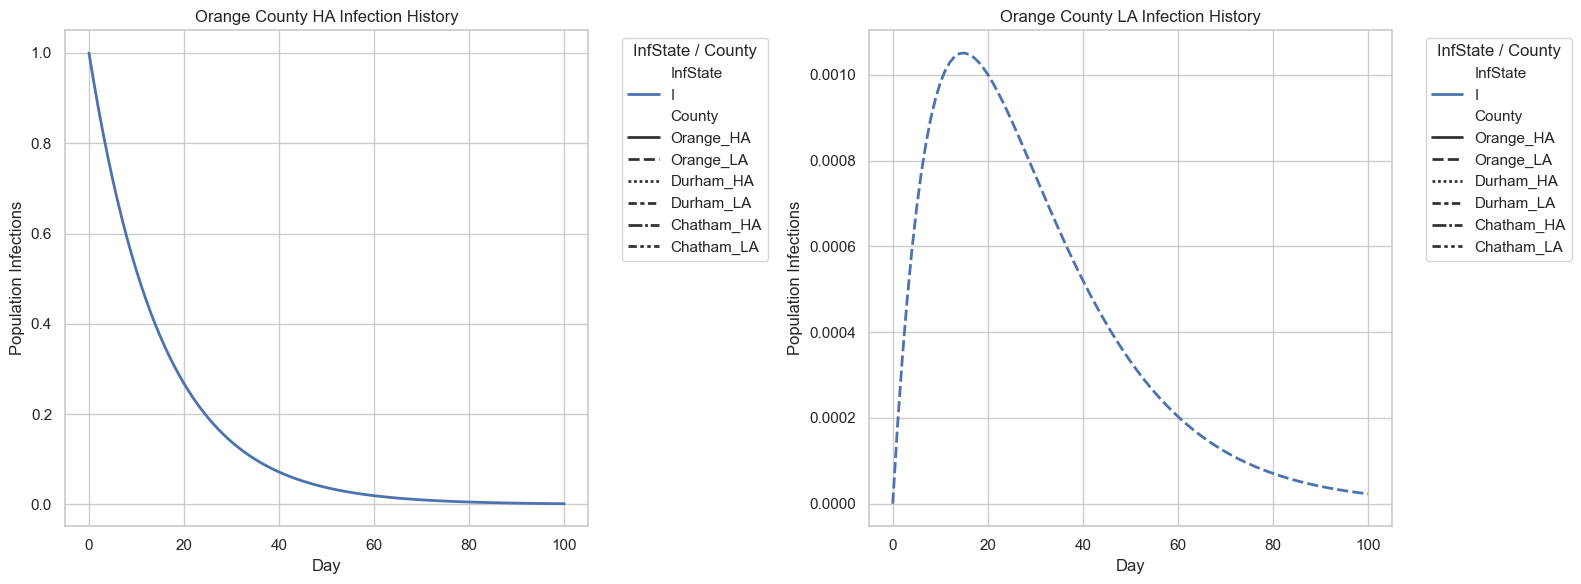

In [52]:
# Set a Seaborn theme for better visuals
sns.set_theme(style="whitegrid")

# Create 1 row, 2 columns subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# === LEFT PLOT: HA Data ===
sns.lineplot(
    data=orange_c_HA_I,
    x="T",
    y="N",
    hue="InfState",
    style="County",
    ax=axes[0],
    linewidth=2
)
axes[0].set_title('Orange County HA Infection History')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Population Infections')
axes[0].legend(title='InfState / County', bbox_to_anchor=(1.05, 1), loc='upper left')

# === RIGHT PLOT: LA Data ===
sns.lineplot(
    data=orange_c_LA_I,
    x="T",
    y="N",
    hue="InfState",
    style="County",
    ax=axes[1],
    linewidth=2
)
axes[1].set_title('Orange County LA Infection History')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Population Infections')
axes[1].legend(title='InfState / County', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [37]:
"""
#100 day, 1000 simulations
mpox_epimdl_1000 = EpiModel(init_state=pop_size, rules=[waifw_mpox_stoc, recovery_rule], stoch_policy='rule_based')

all_sims = pd.DataFrame() #create an empty dataframe

for sim in range(1000): #actual range is 1000
    mpox_epimdl_1000.reset() #reset the model for each fresh simulation

    for t in np.arange(0, 100, 1): #actual range is 100
        mpox_epimdl_1000.do_timestep(dt=1)
    
    current_sim_full_epi = mpox_epimdl_1000.full_epi
    current_sim_full_epi['sim'] = sim
    all_sims = pd.concat([all_sims, current_sim_full_epi])
#time 30min
"""

"\n#100 day, 1000 simulations\nmpox_epimdl_1000 = EpiModel(init_state=pop_size, rules=[waifw_mpox_stoc, recovery_rule], stoch_policy='rule_based')\n\nall_sims = pd.DataFrame() #create an empty dataframe\n\nfor sim in range(1000): #actual range is 1000\n    mpox_epimdl_1000.reset() #reset the model for each fresh simulation\n\n    for t in np.arange(0, 100, 1): #actual range is 100\n        mpox_epimdl_1000.do_timestep(dt=1)\n\n    current_sim_full_epi = mpox_epimdl_1000.full_epi\n    current_sim_full_epi['sim'] = sim\n    all_sims = pd.concat([all_sims, current_sim_full_epi])\n#time 30min\n"

In [38]:
#save 1000 sims to a csv file
#all_sims.to_csv('Mpox_1000_sims.csv', index=False)

In [39]:
#draw S only chart with 1000 simulation lines - county level
#draw I only chart with 1000 simulation lines - county level
#draw R only chart with 1000 simulation lines - county level
"""
all_sim_orange = all_sims[all_sims['County'].str.match(r'^Orange')]
all_sim_durham = all_sims[all_sims['County'].str.match(r'^Durham')]
all_sim_chatham = all_sims[all_sims['County'].str.match(r'^Chatham')]
"""

"\nall_sim_orange = all_sims[all_sims['County'].str.match(r'^Orange')]\nall_sim_durham = all_sims[all_sims['County'].str.match(r'^Durham')]\nall_sim_chatham = all_sims[all_sims['County'].str.match(r'^Chatham')]\n"

In [40]:
#all_sim_orange

In [41]:
#all_sim_orange['County'] = all_sim_orange['County'].cat.remove_unused_categories()

In [42]:
"""
# Set plot style
sns.set_theme(style="whitegrid")

# Create a FacetGrid with one subplot per InfState
g = sns.FacetGrid(all_sim_orange, col="InfState", col_order=["S", "I", "R"], sharey=False, height=4, aspect=1.5)

# Map a lineplot to each subplot
g.map_dataframe(
    sns.lineplot,
    x="T",
    y="N",
    hue="sim",
    style="County",
    linewidth=1.5,
    alpha=0.8
)

# Adjust legend and layout
g.add_legend(title="sim/ County")
g.set_axis_labels("T", "N")
g.set_titles(col_template="InfState = {col_name}")
plt.tight_layout()
plt.show()
"""


'\n# Set plot style\nsns.set_theme(style="whitegrid")\n\n# Create a FacetGrid with one subplot per InfState\ng = sns.FacetGrid(all_sim_orange, col="InfState", col_order=["S", "I", "R"], sharey=False, height=4, aspect=1.5)\n\n# Map a lineplot to each subplot\ng.map_dataframe(\n    sns.lineplot,\n    x="T",\n    y="N",\n    hue="sim",\n    style="County",\n    linewidth=1.5,\n    alpha=0.8\n)\n\n# Adjust legend and layout\ng.add_legend(title="sim/ County")\ng.set_axis_labels("T", "N")\ng.set_titles(col_template="InfState = {col_name}")\nplt.tight_layout()\nplt.show()\n'

#### County level S, I, R 100-day history of 1000 simulations - Stochastic Process, dynamic chart

In [43]:
#epi_fig_stoc_orange_s = px.line(all_sim_orange[all_sim_orange['InfState'] == 'S'], x="T", y="N", color="County", line_dash='sim', title='Orange County S Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_orange_s.show()

In [44]:
#epi_fig_stoc_orange_i = px.line(all_sim_orange[all_sim_orange['InfState'] == 'I'], x="T", y="N", color="County", line_dash='sim', title='Orange County I Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_orange_i.show()

In [45]:
#epi_fig_stoc_orange_r = px.line(all_sim_orange[all_sim_orange['InfState'] == 'R'], x="T", y="N", color="County", line_dash='sim', title='Orange County R Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_orange_r.show()

In [46]:
#epi_fig_stoc_durham_s = px.line(all_sim_durham[all_sim_durham['InfState'] == 'S'], x="T", y="N", color="County", line_dash='sim', title='Durham County S Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_durham_s.show()

In [47]:
#epi_fig_stoc_durham_i = px.line(all_sim_durham[all_sim_durham['InfState'] == 'I'], x="T", y="N", color="County", line_dash='sim', title='Durham County I Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_durham_i.show()

In [48]:
#epi_fig_stoc_durham_r = px.line(all_sim_durham[all_sim_durham['InfState'] == 'R'], x="T", y="N", color="County", line_dash='sim', title='Durham County R Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_durham_r.show()

In [49]:
#epi_fig_stoc_chatham_s = px.line(all_sim_chatham[all_sim_chatham['InfState'] == 'S'], x="T", y="N", color="County", line_dash='sim', title='Chatham County S Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_chatham_s.show()

In [50]:
#epi_fig_stoc_chatham_i = px.line(all_sim_chatham[all_sim_chatham['InfState'] == 'I'], x="T", y="N", color="County", line_dash='sim', title='Chatham County I Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_chatham_i.show()

In [51]:
#epi_fig_stoc_chatham_r = px.line(all_sim_chatham[all_sim_chatham['InfState'] == 'R'], x="T", y="N", color="County", line_dash='sim', title='Chatham County R Population 100-day History of 1000 Simulation - Stochastic')
#epi_fig_stoc_chatham_r.show()